# 3. Data Cleaning, Feature Engineering, and Visual Diagnostics

**Objective:** Apply justified cleaning, perform feature engineering, validate with visual diagnostics.

**Deliverables:** `data/cleaned/zoopla_cleaned.csv`, `data/processed/zoopla_features.csv`; script `src/data_pipeline/impute_area.py`.

In [13]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA_RAW = ROOT / "data" / "raw" / "zoopla_raw.csv"
DATA_CLEANED = ROOT / "data" / "cleaned" / "zoopla_cleaned.csv"
DATA_PROCESSED = ROOT / "data" / "processed" / "zoopla_features.csv"
FIG_DIR = ROOT / "reports" / "figures"
ROOT.mkdir(parents=True, exist_ok=True)
(ROOT / "data" / "cleaned").mkdir(parents=True, exist_ok=True)
(ROOT / "data" / "processed").mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_RAW)
print("Loaded:", len(df))

Loaded: 14438


## 3.1 Preprocessing

- Remove currency symbols from price and convert to numeric.
- Standardise area_sqft (numeric).
- Convert epc_rating to uppercase; treat empty as missing.

In [14]:
# Price: strip £ and commas
df["price"] = pd.to_numeric(df["price"].astype(str).str.replace(r"[\£,]","", regex=True), errors="coerce")
# Area: numeric
df["area_sqft"] = pd.to_numeric(df["area_sqft"], errors="coerce")
# EPC: uppercase, empty string -> NaN
if "epc_rating" in df.columns:
    df["epc_rating"] = df["epc_rating"].astype(str).str.strip().str.upper()
    df["epc_rating"] = df["epc_rating"].replace({"": np.nan, "NAN": np.nan})
print("Price range:", df["price"].min(), "-", df["price"].max())
print("Area (non-null) sample:", df["area_sqft"].dropna().head(3).tolist())

Price range: 4000 - 27500000
Area (non-null) sample: [0, 0, 645]


## 3.2 Duplicate Detection

Primary key: `url`. Fallback: `title` + `address` + `price` (we use url and address + price if url missing).

In [15]:
before = len(df)
df = df.drop_duplicates(subset=["url"], keep="first")
if "address" in df.columns:
    df = df.drop_duplicates(subset=["address", "price"], keep="first")
print(f"Removed {before - len(df)} duplicates; remaining: {len(df)}")

Removed 313 duplicates; remaining: 14125


## 3.3 Missing Value Handling

- **Bedrooms/bathrooms:** Median imputation grouped by property_type (or city if needed).
- **Area:** If missing rate ≤ 20% use predictive imputation (e.g. RandomForest); if > 30% consider removal or missing indicator. Here we use median by property_type for simplicity and call a proper imputer in src.
- **EPC:** Fill with "Unknown", add `epc_missing_flag`.

In [16]:
# Bedrooms/bathrooms: median by property_type
for col in ["bedrooms", "bathrooms"]:
    if col in df.columns:
        med = df.groupby("property_type")[col].transform("median")
        df[col] = df[col].fillna(med).fillna(df[col].median()).astype(int)
# EPC: fill "Unknown", flag
df["epc_missing_flag"] = df["epc_rating"].isna().astype(int)
df["epc_rating"] = df["epc_rating"].fillna("Unknown")
# Area: median by property_type for now; optional: use impute_area.py (RandomForest)
area_missing_pct = df["area_sqft"].isna().mean() * 100
print("Area missing %:", round(area_missing_pct, 2))
df["area_sqft"] = df["area_sqft"].fillna(df.groupby("property_type")["area_sqft"].transform("median"))
df["area_sqft"] = df["area_sqft"].fillna(df["area_sqft"].median())

Area missing %: 0.0


## 3.4 Outlier Treatment

Winsorise price at 1st and 99th percentile to reduce impact of extremes while keeping sample size. We show before/after for justification.

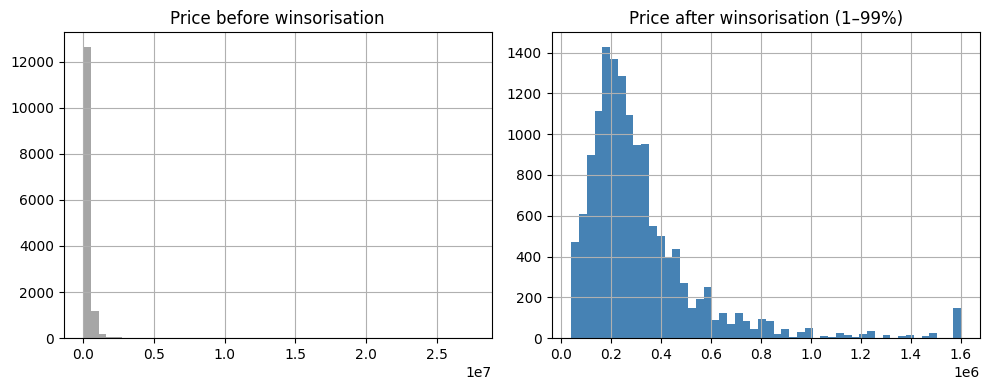

In [17]:
# Before winsorisation
price_before = df["price"].copy()
p1, p99 = df["price"].quantile(0.01), df["price"].quantile(0.99)
df["price"] = df["price"].clip(lower=p1, upper=p99)
# Visual: before vs after
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
price_before.hist(ax=axes[0], bins=50, color="gray", alpha=0.7)
axes[0].set_title("Price before winsorisation")
df["price"].hist(ax=axes[1], bins=50, color="steelblue")
axes[1].set_title("Price after winsorisation (1–99%)")
plt.tight_layout()
plt.savefig(FIG_DIR / "price_before_after_winsor.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.5 Feature Engineering

- `price_per_sqft` = price / area_sqft (avoid div by zero: use area_sqft where area_sqft > 0, else NaN then fill).
- `total_rooms` = bedrooms + bathrooms + living_rooms.
- Size category: small / medium / large by area quartiles.
- EPC score: A→7, B→6, ..., G→1, Unknown→0.
- Text flags from description: has_garden, has_parking, has_balcony, is_renovated.
- postcode_area from address (UK regex).

In [18]:
# price_per_sqft (where area > 0)
df["price_per_sqft"] = np.where(df["area_sqft"] > 0, df["price"] / df["area_sqft"], np.nan)
# Fill with median price_per_sqft by property_type where area was 0
med_pps = df.groupby("property_type")["price_per_sqft"].transform("median")
df["price_per_sqft"] = df["price_per_sqft"].fillna(med_pps).fillna(df["price_per_sqft"].median())
# total_rooms
df["total_rooms"] = df["bedrooms"].fillna(0) + df["bathrooms"].fillna(0) + df.get("living_rooms", pd.Series(0, index=df.index)).fillna(0)
# Size category by area quartiles (use positive area only so bins are unique)
area_positive = df.loc[df["area_sqft"] > 0, "area_sqft"]
if len(area_positive) >= 2:
    q = area_positive.quantile([0.33, 0.66])
    q0, q1 = float(q.iloc[0]), float(q.iloc[1])
    if q0 < q1:
        bins = [0, q0, q1, np.inf]
        df["size_category"] = pd.cut(df["area_sqft"], bins=bins, labels=["small", "medium", "large"])
        df["size_category"] = df["size_category"].fillna("small")
    else:
        df["size_category"] = np.where(df["area_sqft"] > 0, "medium", "small")
else:
    df["size_category"] = np.where(df["area_sqft"] > 0, "medium", "small")
# EPC score A=7 ... G=1, Unknown=0
epc_map = {"A": 7, "B": 6, "C": 5, "D": 4, "E": 3, "F": 2, "G": 1}
df["epc_score"] = df["epc_rating"].map(epc_map).fillna(0).astype(int)
# Text flags from description
desc = df["description"].fillna("").astype(str).str.lower()
df["has_garden"] = (desc.str.contains("garden")).astype(int)
df["has_parking"] = (desc.str.contains("parking|driveway|garage")).astype(int)
df["has_balcony"] = (desc.str.contains("balcony|terrace")).astype(int)
df["is_renovated"] = (desc.str.contains("renovat|refurbish|modern")).astype(int)
# Postcode area (UK: e.g. SW11, M27, CR2)
def extract_postcode_area(addr):
    if pd.isna(addr): return None
    m = re.search(r"\b([A-Z]{1,2}\d{1,2}[A-Z]?)\s*\d", str(addr).upper())
    return m.group(1) if m else None
df["postcode_area"] = df["address"].apply(extract_postcode_area)
print("New features:", [c for c in df.columns if c not in pd.read_csv(DATA_RAW).columns])

New features: ['epc_missing_flag', 'price_per_sqft', 'total_rooms', 'size_category', 'epc_score', 'has_garden', 'has_parking', 'has_balcony', 'is_renovated', 'postcode_area']


## 3.6 Visual Diagnostics

Before/after distributions, price_per_sqft distribution, city comparison.

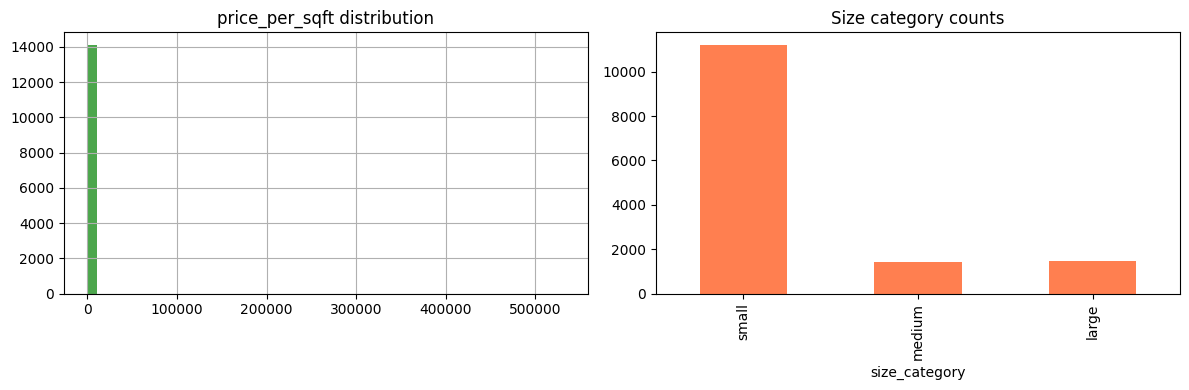

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["price_per_sqft"].hist(ax=axes[0], bins=50, color="green", alpha=0.7)
axes[0].set_title("price_per_sqft distribution")
df["size_category"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Size category counts")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_price_per_sqft_size.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
# Save cleaned and feature datasets
df.to_csv(DATA_CLEANED, index=False)
print("Saved cleaned:", DATA_CLEANED)
# Features dataset (exclude long text for ML)
drop_cols = ["description"]
feat_cols = [c for c in df.columns if c not in drop_cols]
df[feat_cols].to_csv(DATA_PROCESSED, index=False)
print("Saved features:", DATA_PROCESSED)

Saved cleaned: /Users/hoamai/Personal/bradford/AI_AND_DATASCIENCE/final_v1/data/cleaned/zoopla_cleaned.csv
Saved features: /Users/hoamai/Personal/bradford/AI_AND_DATASCIENCE/final_v1/data/processed/zoopla_features.csv
